# mask2graph: YAML-driven mask → graph → rotate → flip → crop

This notebook deliberately contains **no behavioral experiment parameters**. The single source of behavior is `configs/retinal_augmentation_demo.yaml`. The same YAML is accepted by the `mask2graph` CLI, and the notebook calls the same `run_experiment(...)` execution path.


In [1]:
from pathlib import Path
import sys
from IPython.display import Image, display

ROOT = Path.cwd().resolve()
if not (ROOT / 'mask2graph').is_dir():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from mask2graph import load_run_config, run_experiment

CONFIG_PATH = ROOT / 'configs' / 'retinal_augmentation_demo.yaml'
cfg = load_run_config(CONFIG_PATH)
print('config:', CONFIG_PATH)
print('input:', cfg.input.path)
print('run dir:', cfg.output.run_dir)


config: /home/ri/Desktop/Projects/mask2graph/configs/retinal_augmentation_demo.yaml
input: /home/ri/Desktop/Projects/mask2graph/notebooks/data/retinal_binary_mask.gif
run dir: /home/ri/Desktop/Projects/mask2graph/runs/retinal_augmentation_demo


## Execute the canonical pipeline
The run archives source/resolved YAML, environment metadata, a first-party code snapshot, stage graphs, figures, and final `min_ipd` output according to the YAML.


In [2]:
run = run_experiment(CONFIG_PATH)
print('stages:', [s.name for s in run.stages])
print('final graph hash:', run.final.topology_graph.meta.graph_hash)


stages: ['00_extracted', '01_rotate', '02_flip', '03_central_crop']
final graph hash: 97d11ddd396caff3ac8e95d4e1051cea2230d08d4697d91b15bd9dad41ac09ff


## 1. Original binary mask


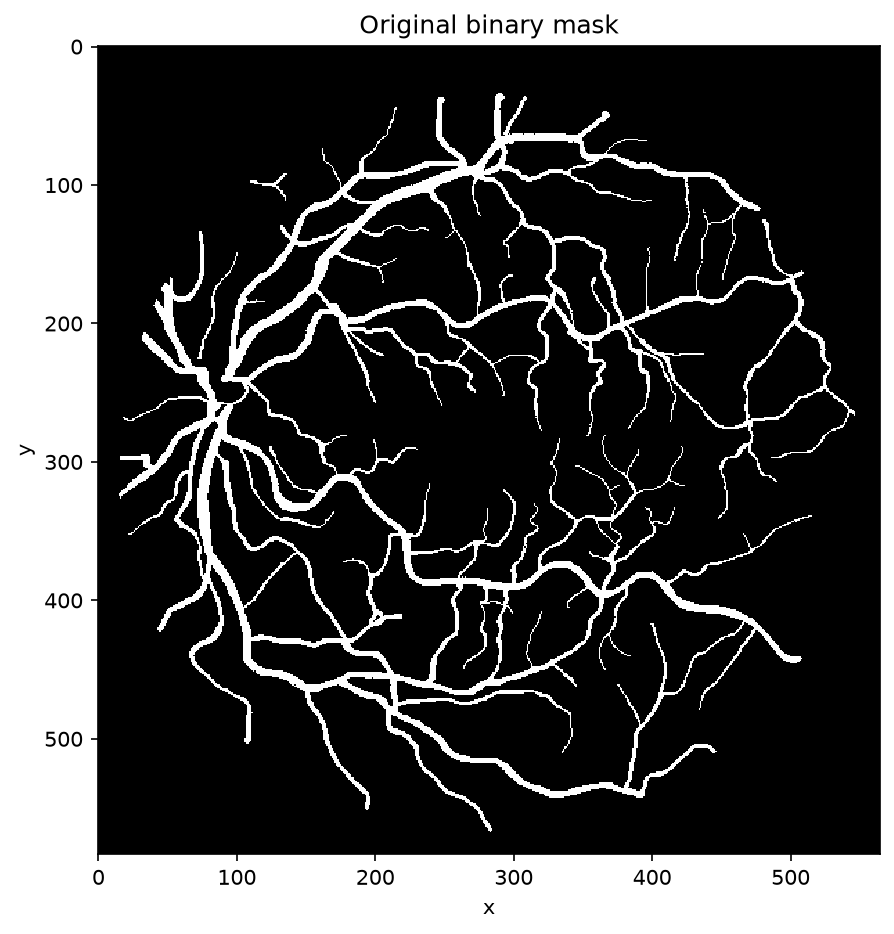

In [3]:
display(Image(filename=str(run.run_dir / 'figures' / '00_original_mask.png')))


## 2. Extracted graph over the original mask


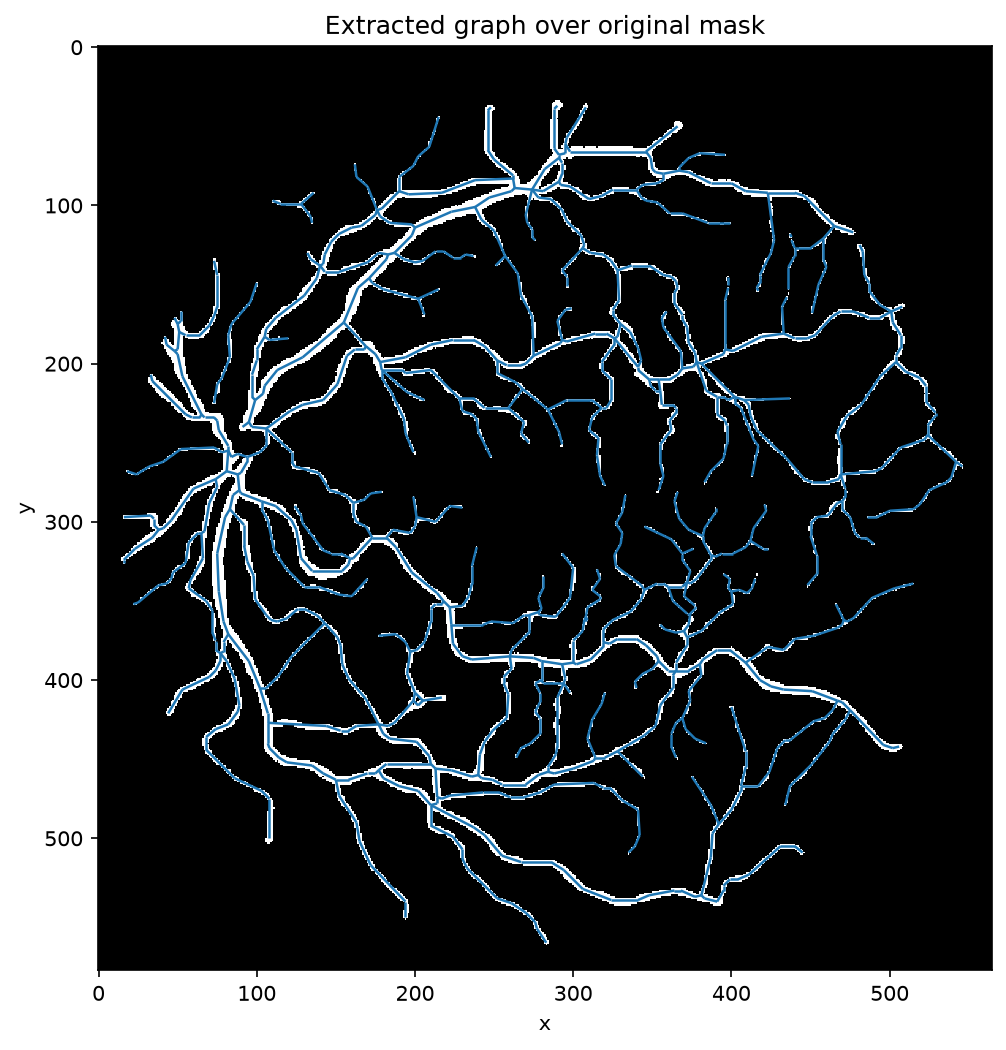

In [4]:
display(Image(filename=str(run.run_dir / 'figures' / '01_graph_overlay.png')))


## 3. Rotated graph


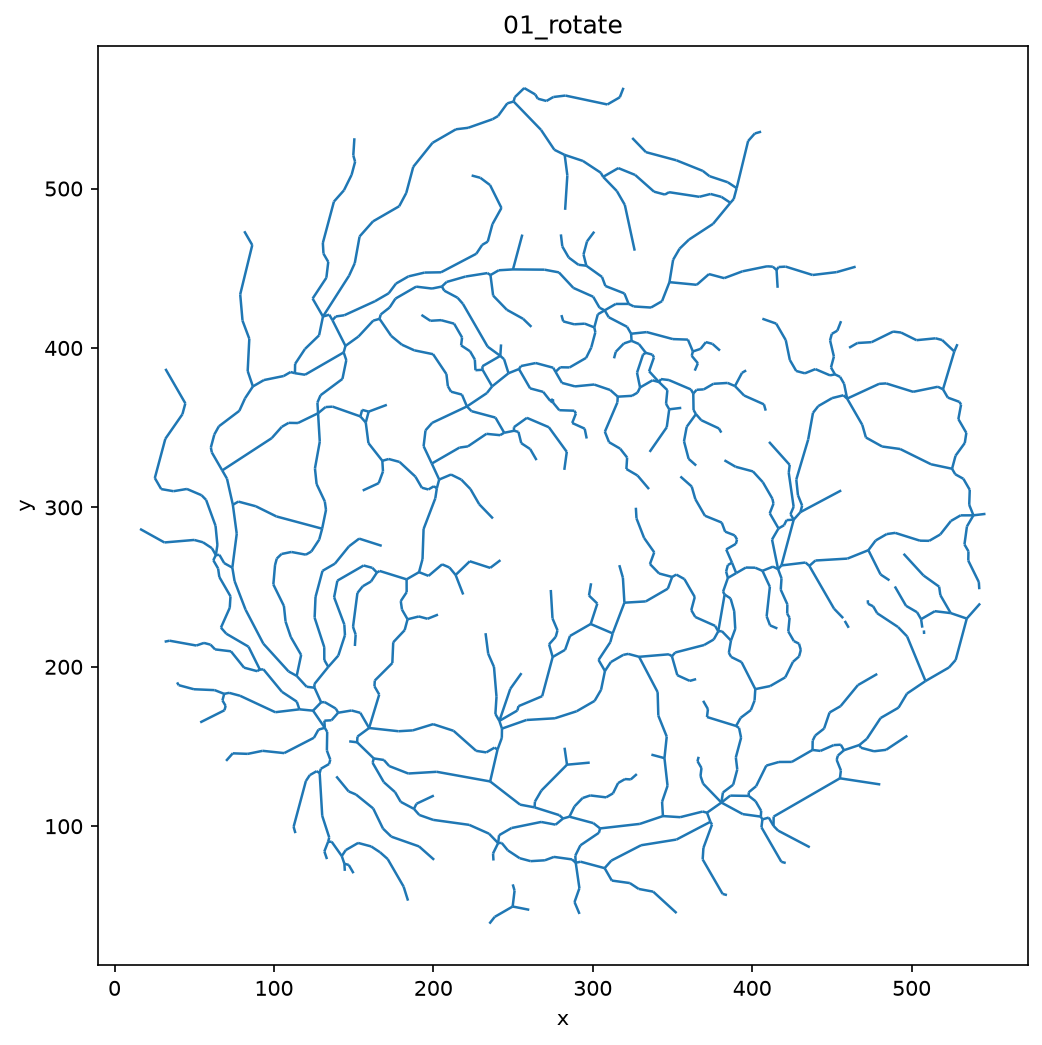

In [5]:
display(Image(filename=str(run.run_dir / 'figures' / '01_rotate.png')))


## 4. Rotated + flipped graph


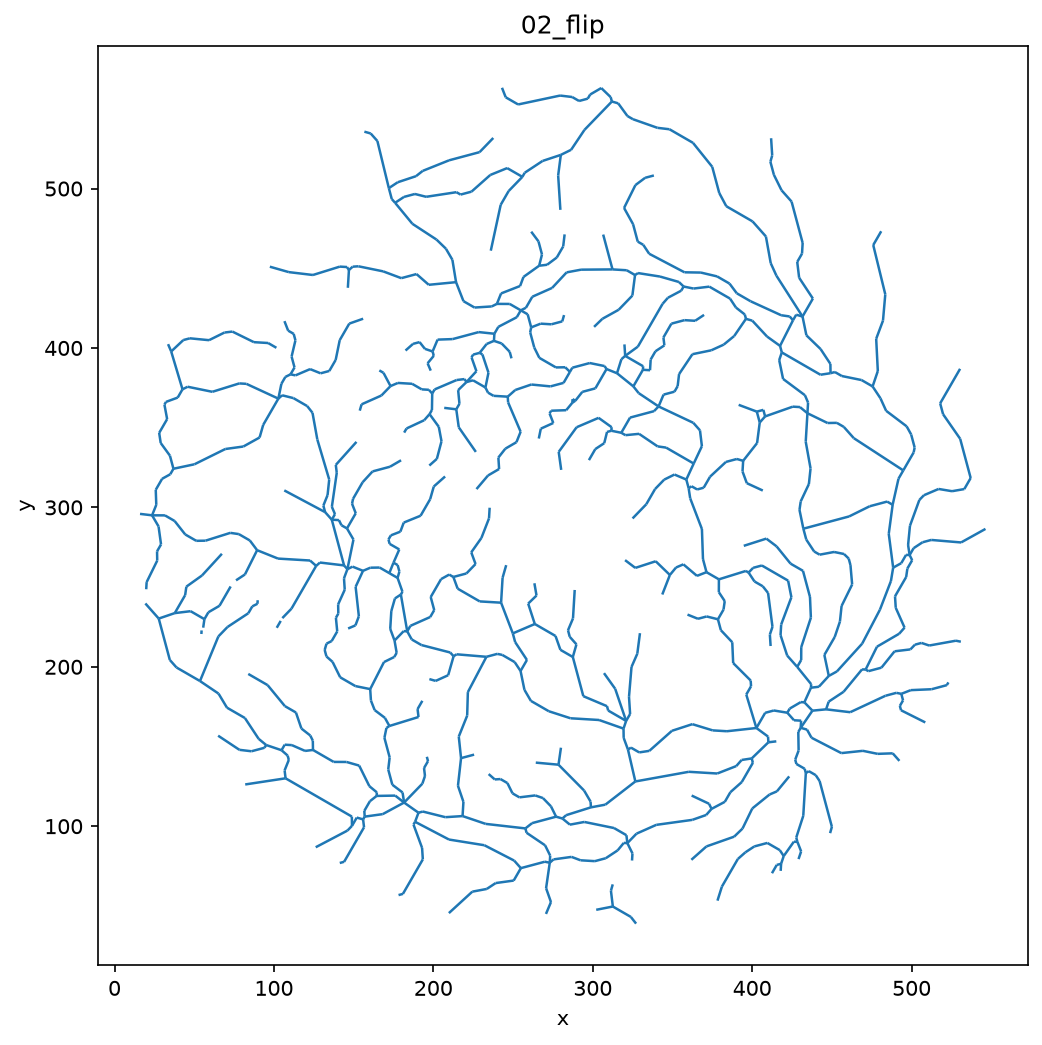

In [6]:
display(Image(filename=str(run.run_dir / 'figures' / '02_flip.png')))


## 5. Cropped graph


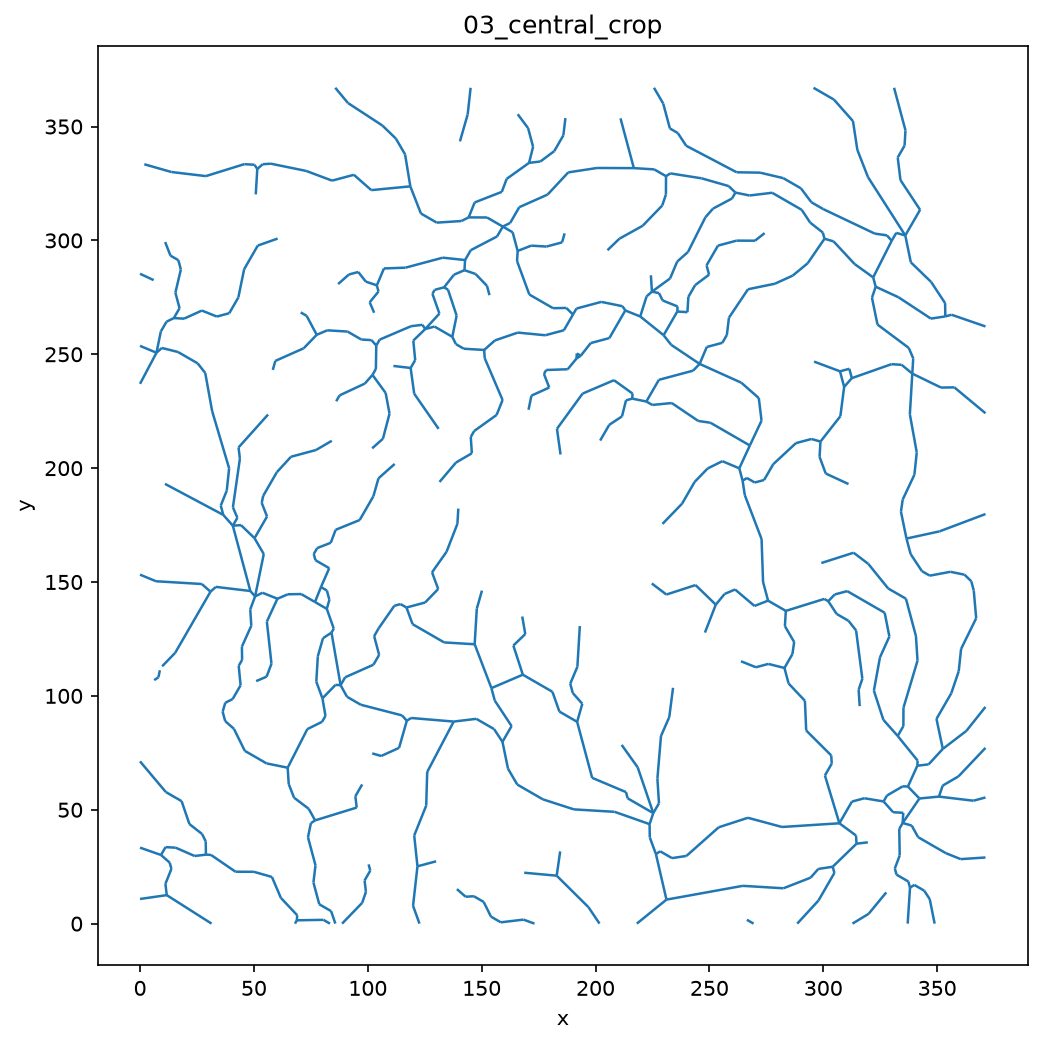

In [7]:
display(Image(filename=str(run.run_dir / 'figures' / '03_central_crop.png')))


## All stages side by side


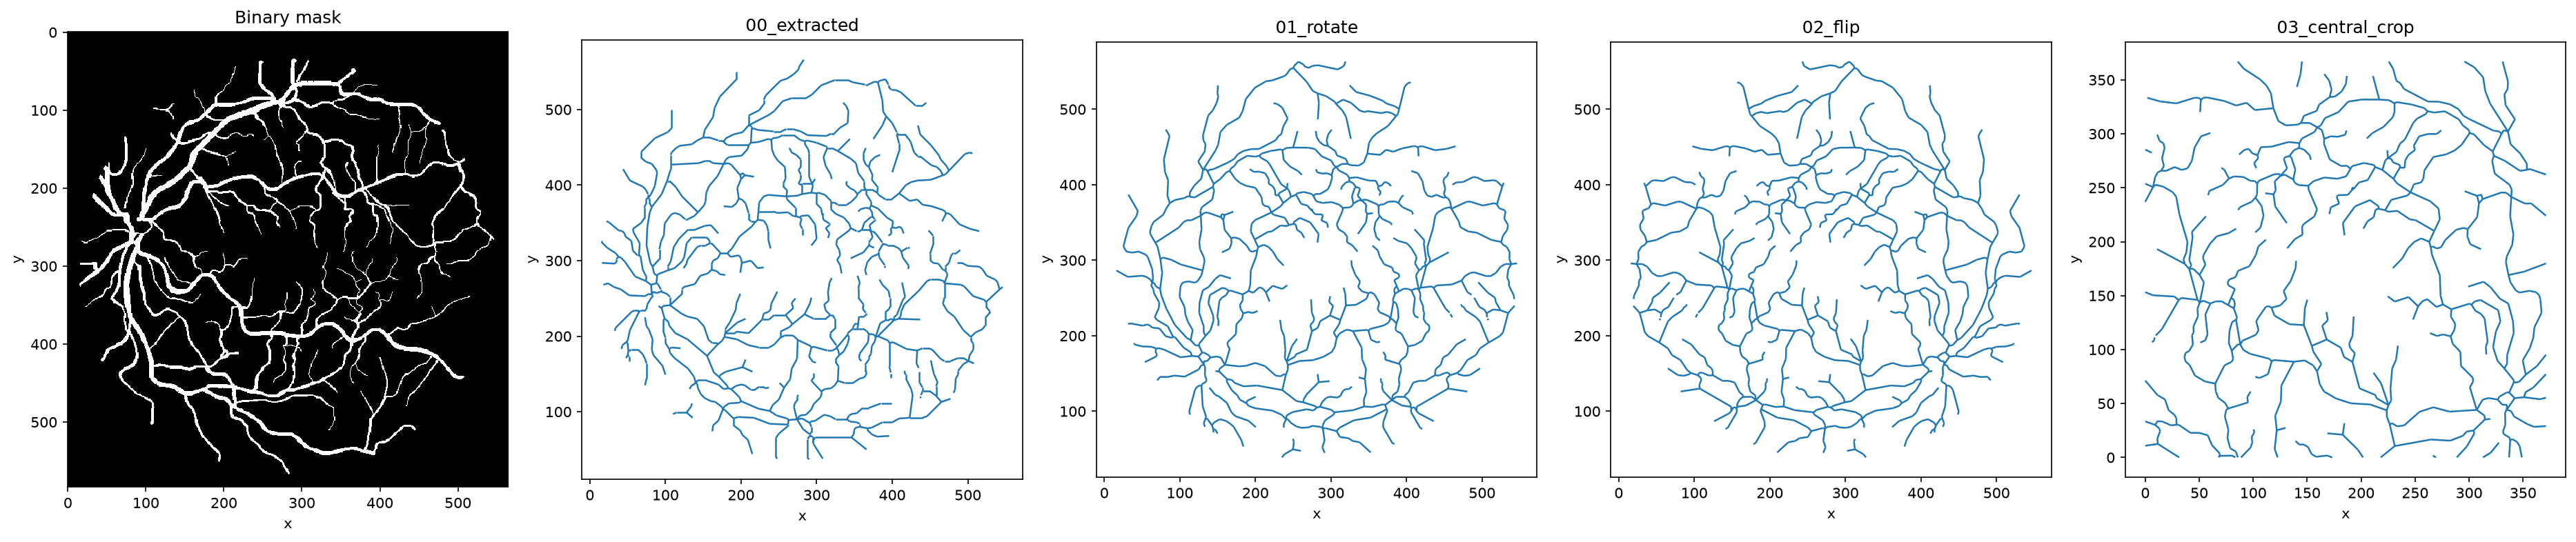

In [8]:
display(Image(filename=str(run.run_dir / 'figures' / 'augmentation_sequence.png')))


## Auditable run summary


In [9]:
import json
summary = json.loads((run.run_dir / 'summary.json').read_text())
summary


{'augmentation_seed': 1234,
 'extract_config_hash': 'a86dac512121221dab77c347632b29627f64009d8c02db305c7f3104f0d4331f',
 'final_graph_hash': '97d11ddd396caff3ac8e95d4e1051cea2230d08d4697d91b15bd9dad41ac09ff',
 'input_hash': '8edfeac3c31f28e97b5a4b63788d5a83c0488d2eed45f1a48dd346ce51f018e7',
 'name': 'retinal_augmentation_demo',
 'resolved_config_sha256': 'b4f3fb20a14da62eb5c14db5afc294c3445d26ce543b9fb79ef4f7e6dc9bc560',
 'source_graph_hash': '8c8c8a956877940687cb2e964c621e761a686969bb20db2f043fd9f14eb0c319',
 'stages': [{'beta0': 7,
   'beta1': 34,
   'edges': 269,
   'embedded_segments': 986,
   'embedded_vertices': 959,
   'graph_hash': '8c8c8a956877940687cb2e964c621e761a686969bb20db2f043fd9f14eb0c319',
   'name': '00_extracted',
   'nodes': 242},
  {'beta0': 7,
   'beta1': 34,
   'edges': 269,
   'embedded_segments': 986,
   'embedded_vertices': 959,
   'graph_hash': '609c244fcd1e092e51717f5ea3f25ed41592ebc6381167dc131d2992fb27fd51',
   'name': '01_rotate',
   'nodes': 242},
  {'be

### Changing behavior
Edit or copy the YAML file. Do **not** change augmentation angles, crop fractions, simplifier settings, spacing, seed, or export policy in notebook cells. For final minimum-segment PSLG experiments, set `extract.simplify.method: optimal` in YAML.
